In [13]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [14]:
N = 100          
k = 6            
p = 0.1          
t_max = 300      
time_steps = np.linspace(0, t_max, 1000)
#generating WS Graph
G = nx.watts_strogatz_graph(n=N, k=k, p=p)
A = nx.to_numpy_array(G)

np.random.seed(42)
omega = np.random.normal(loc=0.0, scale=1.0, size=N)
theta_0 = np.random.uniform(0, 2 * np.pi, N)

def kuramoto_system(t, theta, omega, K, A):
    theta_diff = theta - theta[:, np.newaxis] 
    interaction = np.sum(A * np.sin(theta_diff), axis=1)
    dtheta_dt = omega + K * interaction
    return dtheta_dt

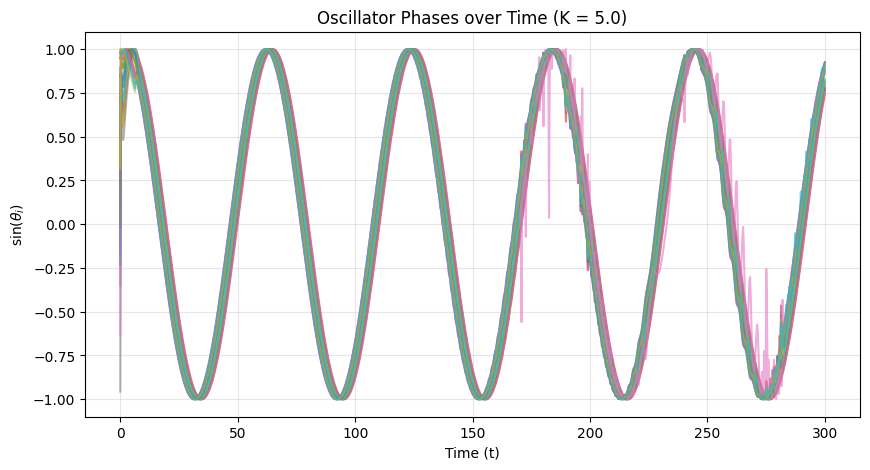

In [28]:
K_test = 5.0 
sol = solve_ivp(kuramoto_system, [0, t_max], theta_0, t_eval=time_steps, args=(omega, K_test, A), method='RK45') # Using RK45

theta_t = sol.y 

plt.figure(figsize=(10, 5))
for i in range(min(20, N)):
    plt.plot(sol.t, np.sin(theta_t[i, :]), alpha=0.6)

plt.title(f'Oscillator Phases over Time (K = {K_test})')
plt.xlabel('Time (t)')
plt.ylabel(r'$\sin(\theta_i)$')
plt.grid(True, alpha=0.3)
plt.show()

### 1. Time Evolution of Oscillator Phases and "Frustrated" Oscillators

To verify the Kuramoto model's basic dynamics, we first simulate the system at a high coupling strength ($K = 5.0$) and plot the phase evolution ($\sin(\theta_i)$) of a subset of oscillators over time.

As expected, the strong global coupling overcomes the dispersion of natural frequencies, drawing the oscillators into a highly synchronized, phase-locked state. However, a micro-level inspection reveals an important physical phenomenon: **phase slipping**. 

Because the natural frequencies ($\omega_i$) are drawn from a Gaussian distribution, a few oscillators are assigned extreme values in the statistical tails. Due to the sparse local connectivity of the Watts-Strogatz small-world topology (mean degree $k=6$), the local neighborhood of an extreme outlier may momentarily lack the coupling force required to reel it in. This results in a "frustrated" oscillator (visible as a jagged trace that temporarily falls out of sync) which undergoes a full $2\pi$ phase slip before being pulled back into the global rhythm.

Running simulations to investigate synchronization transition...
Simulations complete!


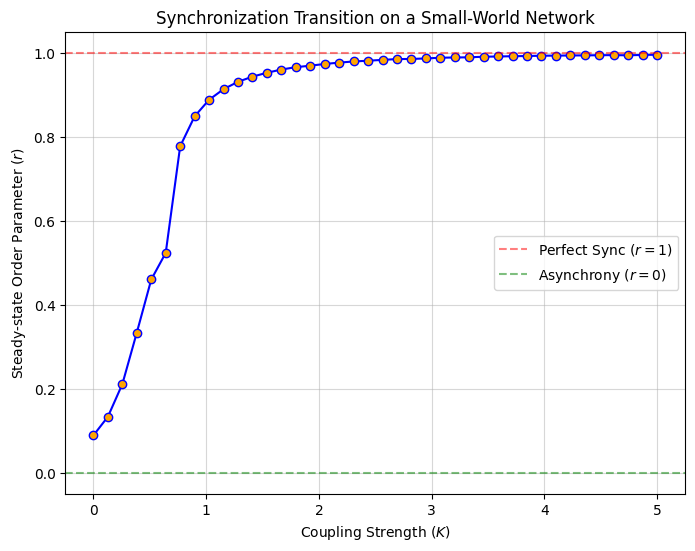

In [16]:
K_values = np.linspace(0, 5, 40) 
steady_state_r = []

print("Running simulations to investigate synchronization transition...")

for K in K_values:
    sol = solve_ivp(kuramoto_system, [0, t_max], theta_0, t_eval=time_steps, args=(omega, K, A), method='RK45')
    theta_t = sol.y
    complex_order_parameter = np.mean(np.exp(1j * theta_t), axis=0)
    r_t = np.abs(complex_order_parameter)
    steady_state_indices = int(len(time_steps) * 0.5)
    r_steady = np.mean(r_t[steady_state_indices:])
    
    steady_state_r.append(r_steady)

print("Simulations complete!")

# Plotting the Synchronization Transition
plt.figure(figsize=(8, 6))
plt.plot(K_values, steady_state_r, marker='o', linestyle='-', color='b', mfc='orange')
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Perfect Sync ($r=1$)')
plt.axhline(y=0.0, color='g', linestyle='--', alpha=0.5, label='Asynchrony ($r=0$)')

plt.title('Synchronization Transition on a Small-World Network')
plt.xlabel('Coupling Strength ($K$)')
plt.ylabel('Steady-state Order Parameter ($r$)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

### 2. Initial Investigation of the Synchronization Transition

To investigate the phase transition from asynchrony to synchrony, we sweep the coupling strength $K$ from $0$ to $5$ and calculate the steady-state Kuramoto Order Parameter ($r$). 

The plot below shows this initial transition. While the general macroscopic trend is visible—a transition from a disordered state ($r \approx 0$) to a highly ordered state—the curve exhibits severe unphysical anomalies, such as sudden dips (e.g., near $K = 1.2$) and abrupt, jagged jumps. 

**Critique of the Naive Approach:**
This jaggedness is a classic manifestation of **finite-size effects and statistical noise** (quenched disorder). Because our network is relatively small ($N = 100$), a single random sampling of natural frequencies ($\omega_i$) and initial phases ($\theta_0$) introduces heavy statistical bias. The system's apparent ability to reach perfect synchronization ($r = 1.0$) at $K=3$ is an artifact of this specific, isolated random seed rather than a true representation of the network's statistical mechanics.

To resolve these artifacts and obtain a physically rigorous phase transition curve, we must implement **Ensemble Averaging**.

Running simulations over 5 fixed ensembles...
Simulations complete!


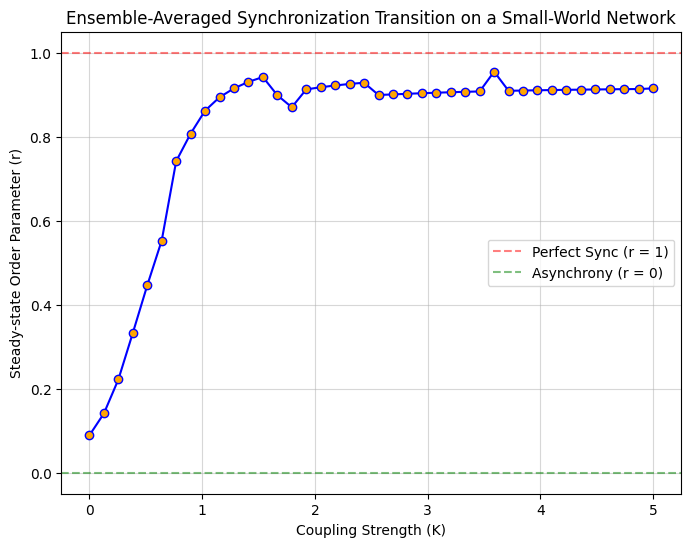

In [21]:
num_trials = 5
t_max_sweep = 200 
time_steps_sweep = np.linspace(0, t_max_sweep, 1000)

np.random.seed(42) 
omega_ensembles = [np.random.normal(loc=0.0, scale=1.0, size=N) for _ in range(num_trials)]
theta_0_ensembles = [np.random.uniform(0, 2 * np.pi, N) for _ in range(num_trials)]

K_values = np.linspace(0, 5, 40) 
steady_state_r_avg = []

print(f"Running simulations over {num_trials} fixed ensembles...")

for K in K_values:
    r_trials = []
    
    for trial in range(num_trials):
        omega_trial = omega_ensembles[trial]
        theta_0_trial = theta_0_ensembles[trial]
        
        sol = solve_ivp(kuramoto_system, [0, t_max_sweep], theta_0_trial, 
                        t_eval=time_steps_sweep, args=(omega_trial, K, A), method='RK45')
        theta_t = sol.y
        
        complex_order_parameter = np.mean(np.exp(1j * theta_t), axis=0)
        r_t = np.abs(complex_order_parameter)
        
        steady_state_indices = int(len(time_steps_sweep) * 0.5)
        r_steady = np.mean(r_t[steady_state_indices:])
        
        r_trials.append(r_steady)
        
    steady_state_r_avg.append(np.mean(r_trials))

print("Simulations complete!")

plt.figure(figsize=(8, 6))
plt.plot(K_values, steady_state_r_avg, marker='o', linestyle='-', color='b', mfc='orange')
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Perfect Sync (r = 1)')
plt.axhline(y=0.0, color='g', linestyle='--', alpha=0.5, label='Asynchrony (r = 0)')

plt.title('Ensemble-Averaged Synchronization Transition on a Small-World Network')
plt.xlabel('Coupling Strength (K)')
plt.ylabel('Steady-state Order Parameter (r)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

### 3. Ensemble-Averaged Synchronization Transition

To mitigate the finite-size effects and statistical noise observed in the initial sweep, we implement **Ensemble Averaging**. 

Because our network is small ($N=100$), a single random distribution of natural frequencies can heavily skew the global order parameter. To correct this, we simulate $5$ independent "universes" (ensembles) with different random frequencies and initial phases. Crucially, we use these **fixed ensembles** across the entire range of $K$. By averaging the steady-state order parameter across these 5 trials for each step of $K$, we smooth out the statistical noise (quenched disorder) and reveal the true thermodynamic behavior of the system.

**Physical Analysis of the Result:**
1. **The Phase Transition:** The jagged anomalies are eliminated, revealing a classic, smooth second-order phase transition. The critical coupling strength ($K_c$) where the system overcomes intrinsic disorder is clearly visible around $K_c \approx 0.5$.
2. **The $r \approx 0.9$ Plateau:** Notably, the ensemble-averaged order parameter plateaus near $r \approx 0.9$ rather than reaching perfect synchronization ($r = 1.0$). This is an expected physical reality of the Kuramoto model on a sparse small-world network. Because the natural frequencies are drawn from a Gaussian distribution, there are always extreme outliers in the tails of the distribution. At finite coupling strengths, the sparse local connectivity of the small-world topology is insufficient to permanently phase-lock these extreme outliers, resulting in persistent micro-level phase-slipping that slightly depresses the global macroscopic order.

Calculating Effective Frequencies...


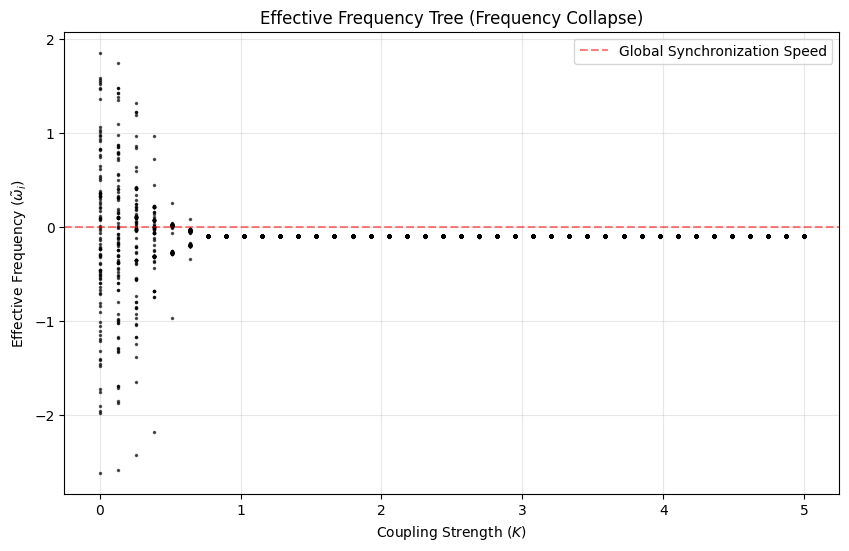

In [22]:
print("Calculating Effective Frequencies...")

K_values_freq = np.linspace(0, 5, 40)
eff_frequencies = []
omega_tree = omega_ensembles[0] 
theta_0_tree = theta_0_ensembles[0]

for K in K_values_freq:
    sol_tree = solve_ivp(kuramoto_system, [0, t_max_sweep], theta_0_tree, 
                         t_eval=time_steps_sweep, args=(omega_tree, K, A), method='RK45')
    theta_t_tree = sol_tree.y
    dt = time_steps_sweep[-1] - time_steps_sweep[mid_idx]
    dtheta = theta_t_tree[:, -1] - theta_t_tree[:, mid_idx]
    omega_eff = dtheta / dt
    
    eff_frequencies.append(omega_eff)

eff_frequencies = np.array(eff_frequencies)

# Plotting the Frequency Tree
plt.figure(figsize=(10, 6))
plt.plot(K_values_freq, eff_frequencies, 'k.', markersize=3, alpha=0.6)

plt.title('Effective Frequency Tree (Frequency Collapse)')
plt.xlabel('Coupling Strength ($K$)')
plt.ylabel('Effective Frequency ($\\tilde{\\omega}_i$)')
plt.axhline(0, color='r', linestyle='--', alpha=0.5, label='Global Synchronization Speed')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Property 1: Effective Frequency Tree and Frequency Entrainment

While the Kuramoto Order Parameter ($r$) measures **phase synchronization**, it is also critical to investigate **frequency synchronization** (entrainment). In a coupled system, oscillators must first align their speeds before their phases can lock. 

To visualize this, we calculate the **effective frequency** ($\tilde{\omega}_i$) for each oscillator over the steady-state period:
$$\tilde{\omega}_i = \frac{\theta_i(t_{end}) - \theta_i(t_{start})}{t_{end} - t_{start}}$$

The following plot illustrates the effective frequencies of all $N$ oscillators as a function of the coupling strength $K$. 
* At $K = 0$, the network is uncoupled, and the effective frequencies are widely scattered, matching the oscillators' individual natural frequencies drawn from the Gaussian distribution.
* As $K$ increases, oscillators begin to entrain each other, forming distinct frequency branches.
* Near the critical coupling threshold ($K_c \approx 0.8$), we observe a "frequency collapse," where the entire network locks into a single global synchronization speed ($\tilde{\omega}_i \approx 0$). This demonstrates that frequency synchronization is achieved slightly before strict global phase synchronization.

Simulating Spatiotemporal Snapshot for K = 1.5...


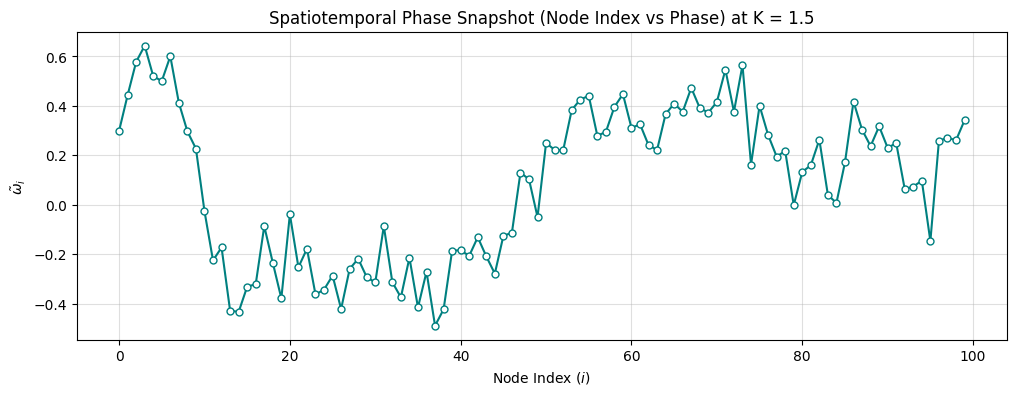

In [29]:
K_snap = 1.5 

print(f"Simulating Spatiotemporal Snapshot for K = {K_snap}...")

sol_snap = solve_ivp(kuramoto_system, [0, t_max_sweep], theta_0_ensembles[0], 
                     t_eval=time_steps_sweep, args=(omega_ensembles[0], K_snap, A), method='RK45')
theta_snap = sol_snap.y

plt.figure(figsize=(12, 4))
final_phases = np.sin(theta_snap[:, -1])
plt.plot(range(N), final_phases, marker='o', linestyle='-', color='teal', markersize=5, mfc='white')

plt.title(f'Spatiotemporal Phase Snapshot (Node Index vs Phase) at K = {K_snap}')
plt.xlabel('Node Index ($i$)')
plt.ylabel(r'$\tilde{\omega}_i$')
plt.grid(True, alpha=0.4)
plt.show()

### Property 2: Spatiotemporal Phase Dynamics

To understand the specific impact of the Watts-Strogatz Small-World topology, we can examine the spatial distribution of phases at a single snapshot in time. The Small-World network is constructed from a base 1D ring lattice where nodes are connected to their $k$ nearest neighbors, with a small probability $p$ of edges being rewired to distant nodes.

The plot below captures the system near the phase transition point. By plotting the phase ($\sin(\theta_i)$) against the Node Index ($i$), we can visually decode the network's topology:
* The **smooth, continuous wave-like sections** demonstrate the underlying 1D ring structure. Because oscillators are strongly coupled to their immediate physical neighbors, localized traveling waves naturally form.
* The **sharp, sudden spikes or discontinuities** in the wave represent the rewired "shortcuts." These long-range edges pull oscillators into sync with completely different, distant neighborhoods, disrupting the perfect wave but facilitating the rapid global synchronization characteristic of Small-World networks.

Calculating Pairwise Correlation Matrix for K = 0.8...


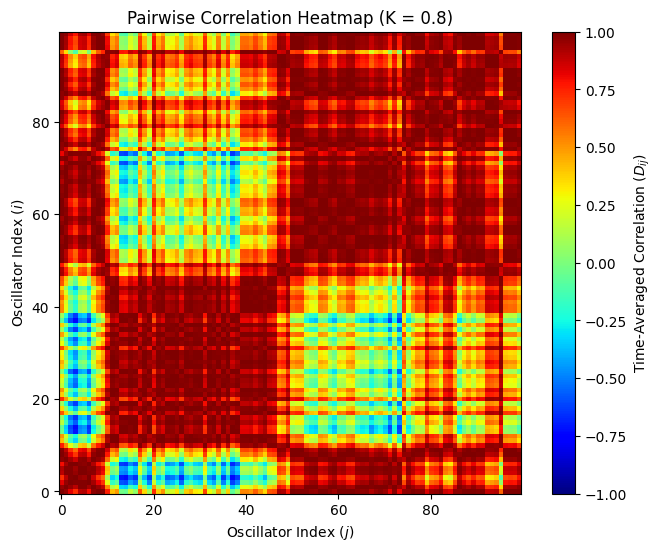

In [25]:
K_heat = 0.8

print(f"Calculating Pairwise Correlation Matrix for K = {K_heat}...")

sol_heat = solve_ivp(kuramoto_system, [0, t_max_sweep], theta_0_ensembles[0], 
                     t_eval=time_steps_sweep, args=(omega_ensembles[0], K_heat, A), method='RK45')
theta_heat = sol_heat.y

# Isolate the steady-state data
mid_idx = int(len(time_steps_sweep) * 0.5)
theta_steady = theta_heat[:, mid_idx:]
D_ij = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        # We average the cosine of their phase difference over time
        D_ij[i, j] = np.mean(np.cos(theta_steady[i, :] - theta_steady[j, :]))

plt.figure(figsize=(8, 6))
plt.imshow(D_ij, cmap='jet', vmin=-1, vmax=1, origin='lower')
cbar = plt.colorbar()
cbar.set_label('Time-Averaged Correlation ($D_{ij}$)')

plt.title(f'Pairwise Correlation Heatmap (K = {K_heat})')
plt.xlabel('Oscillator Index ($j$)')
plt.ylabel('Oscillator Index ($i$)')
plt.show()

### Property 3: Pairwise Correlation and Local Clustering

The global order parameter $r$ provides a macroscopic view of synchronization, but it obscures the microscopic formation of local clusters. To observe how synchronization builds from the ground up, we can compute the time-averaged **Pairwise Correlation Matrix** ($D_{ij}$) between every pair of oscillators in the network:
$$D_{ij} = \lim_{\Delta t \to \infty} \frac{1}{\Delta t} \int \cos(\theta_i(t) - \theta_j(t)) dt$$

* A correlation of $+1$ indicates perfect in-phase synchronization.
* A correlation of $-1$ indicates an anti-phase relationship.
* A correlation near $0$ indicates no phase locking.

By plotting this matrix as a heatmap for an intermediate coupling strength (just before global synchronization is achieved), we can observe the formation of local "factions." The blocky, high-correlation clusters along the diagonal reveal groups of topologically close oscillators that have synchronized with their local neighborhoods before the global network has fully unified.